<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/Hanna/Project/GBR_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**CatBoost Gradient Boosted Regression Model for LOS Prediction**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00


In [4]:
# Import libraries
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib
import json

In [13]:
# Load Data
sparcs_model_v1 = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_model_v1.feather')

In [4]:
sparcs_model_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238636 entries, 0 to 4238635
Data columns (total 33 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   health_service_area      object 
 1   hospital_county          object 
 2   facility_id              object 
 3   age_group                object 
 4   zip_code                 object 
 5   gender                   object 
 6   race                     object 
 7   ethnicity                object 
 8   length_of_stay           int64  
 9   admission_type           object 
 10  disposition              object 
 11  discharge_year           int64  
 12  ccsr_dx_code             object 
 13  ccsr_px_code             object 
 14  apr_drg_code             object 
 15  apr_mdc_code             object 
 16  apr_severity_code        object 
 17  apr_mortality_risk       object 
 18  apr_med_surg_desc        object 
 19  total_charges            float64
 20  payer_medicaid           int64  
 21  payer_me

In [19]:
# Prep Data
model_df = sparcs_model_v1.copy()

# Drop columns we don't want in model
cols_to_drop = [
    'total_charges',
    'los_log',
    'length_of_stay'
]
model_df.drop(columns=cols_to_drop, errors='ignore', inplace=True)

# In object columns, replace 'None' values with 'Missing'
obj_cols = model_df.select_dtypes(include=['object']).columns
model_df[obj_cols] = model_df[obj_cols].fillna('Missing')

In [20]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238636 entries, 0 to 4238635
Data columns (total 30 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   health_service_area      object 
 1   hospital_county          object 
 2   facility_id              object 
 3   age_group                object 
 4   zip_code                 object 
 5   gender                   object 
 6   race                     object 
 7   ethnicity                object 
 8   admission_type           object 
 9   disposition              object 
 10  discharge_year           int64  
 11  ccsr_dx_code             object 
 12  ccsr_px_code             object 
 13  apr_drg_code             object 
 14  apr_mdc_code             object 
 15  apr_severity_code        object 
 16  apr_mortality_risk       object 
 17  apr_med_surg_desc        object 
 18  payer_medicaid           int64  
 19  payer_medicare           int64  
 20  payer_private_insurance  int64  
 21  payer_se

In [5]:
# Save an updated dataframe
df.to_feather('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_model_v2.feather')

model_df = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_model_v2.feather')

In [21]:
# Define target + feature matrix
target_col = 'los_yj'
X = model_df.drop(columns=[target_col])
y = model_df[target_col]

# Identify categorical features
cat_features = X.select_dtypes(include=['object']).columns.tolist()
cat_features

['health_service_area',
 'hospital_county',
 'facility_id',
 'age_group',
 'zip_code',
 'gender',
 'race',
 'ethnicity',
 'admission_type',
 'disposition',
 'ccsr_dx_code',
 'ccsr_px_code',
 'apr_drg_code',
 'apr_mdc_code',
 'apr_severity_code',
 'apr_mortality_risk',
 'apr_med_surg_desc']

In [22]:
from ast import mod
# Train/Validation split
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

# Downsample the training portion
train_samples = 100_000

X_train = X_train_full.sample(n=min(train_samples, len(X_train_full)), random_state=42)
y_train = y_train_full.loc[X_train.index]

print("Training size: ", X_train.shape)
print("Validation size: ", X_val.shape)

Training size:  (100000, 29)
Validation size:  (847728, 29)


In [23]:
# Create catboost pools
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

# Define model
model = CatBoostRegressor(
    task_type='GPU',
    devices='0',
    loss_function='RMSE',
    eval_metric='RMSE',
    depth=8,
    learning_rate=0.05,
    iterations=2000,
    random_seed=42,
    verbose=200,
    early_stopping_rounds=100
)

In [24]:
# Train model
model.fit(train_pool, eval_set=val_pool)

0:	learn: 0.9704751	test: 0.9738084	best: 0.9738084 (0)	total: 111ms	remaining: 3m 41s
200:	learn: 0.4506108	test: 0.4500717	best: 0.4500717 (200)	total: 8.99s	remaining: 1m 20s
400:	learn: 0.4246663	test: 0.4298169	best: 0.4298169 (400)	total: 20.1s	remaining: 1m 20s
600:	learn: 0.4108397	test: 0.4214704	best: 0.4214704 (600)	total: 30.6s	remaining: 1m 11s
800:	learn: 0.4013437	test: 0.4168491	best: 0.4168491 (800)	total: 40.5s	remaining: 1m
1000:	learn: 0.3932280	test: 0.4136291	best: 0.4136291 (1000)	total: 50s	remaining: 49.9s
1200:	learn: 0.3859499	test: 0.4111321	best: 0.4111321 (1200)	total: 1m 1s	remaining: 40.6s
1400:	learn: 0.3788844	test: 0.4088573	best: 0.4088573 (1400)	total: 1m 11s	remaining: 30.8s
1600:	learn: 0.3725666	test: 0.4070888	best: 0.4070888 (1600)	total: 1m 23s	remaining: 20.8s
1800:	learn: 0.3666356	test: 0.4055764	best: 0.4055764 (1800)	total: 1m 32s	remaining: 10.2s
1999:	learn: 0.3608429	test: 0.4042311	best: 0.4042311 (1999)	total: 1m 43s	remaining: 0us
b

In [25]:
# Evaluate Model in transformed space
y_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print('\nModel Performance (Yeo-Johnson Transformed LOS)')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2: {r2:.4f}')


Model Performance (Yeo-Johnson Transformed LOS)
RMSE: 0.4042
MAE: 0.2938
R2: 0.8369


In [27]:
# Inverse-Transform preditions into original LOS units
pt = joblib.load('/content/drive/MyDrive/Sparcs_Datafiles/los_yj_transformer.pkl')

y_val_original = pt.inverse_transform(y_val.values.reshape(-1, 1)).flatten()
y_pred_original = pt.inverse_transform(y_pred.reshape(-1, 1)).flatten()

rmse_orig = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
mae_orig = mean_absolute_error(y_val_original, y_pred_original)
r2_orig = r2_score(y_val_original, y_pred_original)

print('\nModel Performance (Original LOS Units)')
print(f'RMSE: {rmse_orig:.4f}')
print(f'MAE: {mae_orig:.4f}')
print(f'R2: {r2_orig:.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


ValueError: Input contains NaN.

AttributeError: module 'matplotlib.pyplot' has no attribute 'tightlayout'

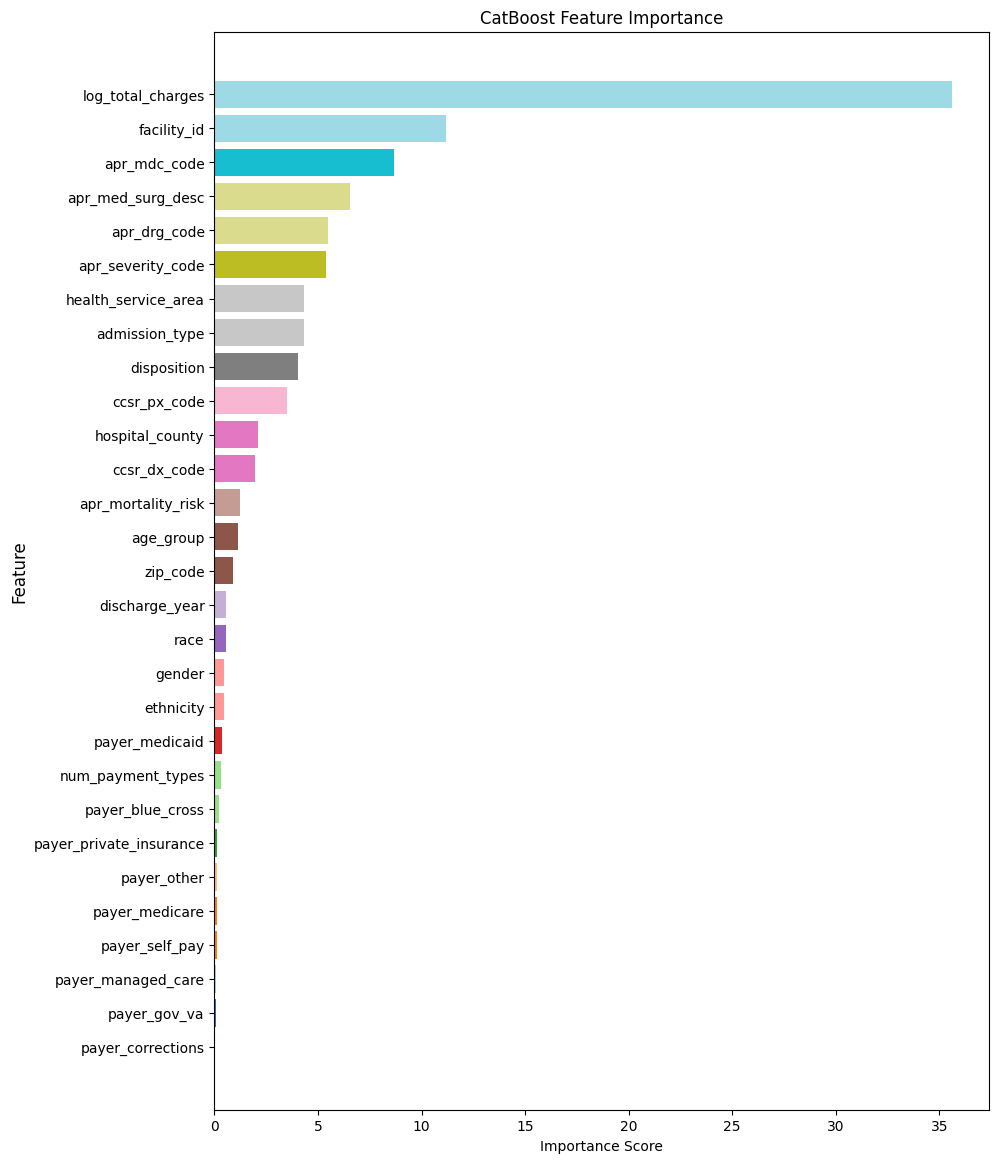

In [31]:
# Feature importance plot
fi = model.get_feature_importance(prettified=True)
fi = fi.sort_values(by='Importances', ascending=True)
colors = plt.cm.tab20(np.linspace(0, 1, len(fi)))

plt.figure(figsize=(10, 14))
plt.barh(fi['Feature Id'], fi['Importances'], color=colors)
plt.xlabel('Importance Score')
plt.ylabel('Feature', fontsize=12)
plt.title('CatBoost Feature Importance')

plt.show()

In [32]:
# Save Model
model.save_model('/content/drive/MyDrive/Sparcs_Datafiles/catboost_los_model_v1.cbm')

metadata = {
    "cat_features": cat_features,
    "feature_order": list(X.columns)
    }

with open("/content/drive/MyDrive/Sparcs_Datafiles/catboost_feature_v1_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print ('\nModel + metadata saved successfully.')


Model + metadata saved successfully.


#**XGBoost Gradient Boosted Regression Model for LOS Prediction**